### Recreating the plots from "The weak scale from BBN" paper 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy

In [2]:
m_u_0 = 2.16  # MeV
m_d_0 = 4.7  # MeV

m_p_0 = 938.272  # MeV
m_n_0 = 939.565  # MeV
m_e_0 = 0.511    # MeV
m_pi0_0 = 134.977  # pi^0 mass in MeV

B_A_O16 = 7.976  # MeV

delta_iso = 2.39   # MeV
delta_EM = (m_n_0 - m_p_0) - delta_iso  # MeV

In [3]:
# Defining a func to calculate m_n - m_p for a given m_u and m_d value

def m_n_minus_m_p(m_u, m_d):
    return delta_iso * (m_d - m_u) / (m_d_0 - m_u_0) + delta_EM

In [4]:
# Importing the B_A for O16 vs m_pi^2 data from arxiv:0712.2968 figure 3

B_A_df = np.loadtxt("digitized-plots/Weak-scale-BBN-plots/arxiv-0712-2968/B_A-vs-m_pi_2_ratio.csv", delimiter=",") 

# interpolating the B_A values for a given m_pi^2/m_pi^2_0 value

B_A_func = scipy.interpolate.interp1d(B_A_df[:, 0], B_A_df[:, 1], kind='cubic', fill_value="extrapolate")

In [5]:
# Finding all values of m_u and m_d that satisfy the condition B_A_O16_func(m_u, m_d) = m_n - m_p - m_e 

m_u = np.geomspace(0.5, 10, 100)  # MeV
m_d = np.geomspace(1, 20, 100)  # MeV 

nuclear_stability_thresh = [[], []]

for m_u_val in m_u:
    for m_d_val in m_d:

        ratio = (m_u_val + m_d_val) / (m_u_0 + m_d_0)

        if ratio < 1.3: 

            check = np.isclose(np.abs(B_A_func(ratio)), m_n_minus_m_p(m_u_val, m_d_val) - m_e_0, atol=0.1)

            if check:
                nuclear_stability_thresh[0].append(m_u_val)
                nuclear_stability_thresh[1].append(m_d_val)


# Defining a function to interpolate the nuclear stability threshold values
nuclear_stability_func = scipy.interpolate.interp1d(nuclear_stability_thresh[0], nuclear_stability_thresh[1], kind='linear', fill_value="extrapolate")

(0.9, 20)

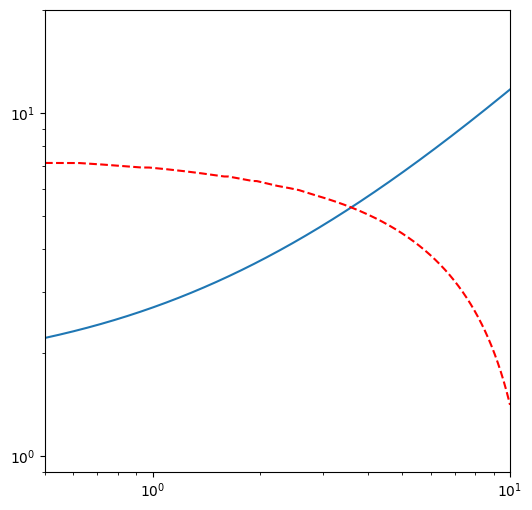

In [6]:
# Hydrogen instability condition: m_n - m_p < m_e

m_u = np.geomspace(0.5, 10, 1000)  # MeV

plt.figure(figsize=(6, 6))

plt.loglog(m_u, m_u + (m_d_0 - m_u_0) * (m_e_0 - delta_EM)/delta_iso, label='Hydrogen Instability Condition')
plt.loglog(m_u, nuclear_stability_func(m_u), 'r--', label='Nuclear Stability Threshold')

plt.xlim(0.5, 10)
plt.ylim(0.9, 20)